In [20]:
import time
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from line_profiler import profile
import logging
import time
import joblib 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output = "pandas")

from captum.attr import IntegratedGradients, LayerConductance, NeuronConductance
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset, IterableDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter('runs/kags4e7')

import gc
torch.cuda.empty_cache()
gc.collect()

4240

In [ ]:
def prep_data(load_path, save_path, train=True):
    df = pd.read_csv(load_path) 
    print(df.info())

    # Data prep
    # Basic data mod of train data
    df = df.drop(columns=['id'])
    df['Gender'] = df.Gender.replace({"Female":0, 'Male':1}).astype(np.int8)
    df['Vehicle_Age'] = df.Vehicle_Age.replace({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2}).astype(np.int8)
    df['Vehicle_Damage']  = df.Vehicle_Damage.replace({'No':0, 'Yes':1}).astype(np.int8)

    list_int = ['Vehicle_Age','Vintage','Policy_Sales_Channel','Region_Code']
    list_bool = ['Driving_License', 'Previously_Insured', 'Vehicle_Damage', 'Gender']
    list_float = ['Annual_Premium','Age']
    list_target = ['Response']

    df[list_int] = df[list_int].astype(np.int32)
    # Optimize integer columns
    if train:
        int_columns = list_int + list_bool + list_target
    else:
        int_columns = list_int + list_bool
        
    for col in int_columns:
        col_min = df[col].min()
        col_max = df[col].max()
        if col_min >= -128 and col_max <= 127:
            df[col] = df[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            df[col] = df[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            df[col] = df[col].astype(np.int32)

    df[list_float] = df[list_float].astype(np.float)

    print(df.info())
    df.to_parquet(save_path)
    del df
    return 

prep_data('data/raw/train.csv', 'data/artifacts/train.parquet')
# 1+ GB -> 209 MB
#prep_data('data/raw/test.csv', 'data/artifacts/test.parquet', train=False)
# 644 MB -> 132 MB

In [ ]:
def save_small(path_load, path_save):
    
    df = pd.read_parquet(path_load)
    vc = df.Response.value_counts()
    print(vc[1]/vc[0])
    y = df.pop("Response")
    
    Xtrain,_,ytrain,_ = train_test_split(df, y, train_size=int(1e5), stratify=y)
    del df, y
    
    vc = ytrain.value_counts()
    print(vc[1]/vc[0])
    
    df_small = pd.concat([Xtrain, ytrain], axis=1)
    df_small.to_parquet(path_save)
    return

save_small('data/artifacts/train.parquet','data/artifacts/train_small.parquet')

In [21]:
class Model(nn.Module):
    def __init__(self, in_features, h1=20, h2=30,d_out=2):
        super().__init__()
        
        self.fc1 = nn.Linear(in_features, h1)
        self.relu1 = nn.SiLU()
        self.bn1 = nn.BatchNorm1d(h1)
        self.dp1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(h1, h2)
        self.relu2 = nn.SiLU()
        self.bn2 = nn.BatchNorm1d(h2)
        self.dp2 = nn.Dropout(0.1)

        self.out = nn.Linear(h2,d_out)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.bn1(x)
        x = self.dp1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.bn2(x)
        x = self.dp2(x)
        x = self.out(x)
        return x

In [26]:
class InsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
    
    @profile
    def __getitem__(self, idx):
        features = self.X[idx]
        target   = self.y[idx]  
        return features, target


In [59]:
BATCH_SIZE = 1000

def load_data(path_load, batch_size):
    df = pd.read_parquet(path_load)
    y = df.pop('Response')
    
    list_int = ['Vehicle_Age','Vintage','Policy_Sales_Channel','Region_Code']
    list_bool = ['Driving_License', 'Previously_Insured', 'Vehicle_Damage', 'Gender']
    list_float = ['Annual_Premium','Age']
    list_target = ['Response']
    
    # Calc imbalance
    class_no = pd.DataFrame(y.to_numpy()).value_counts()/len(y)
    #print(class_no)
    no_features = df.shape[1]
    
    Xtrain, Xtest, ytrain, ytest = train_test_split(df, y, test_size=0.1, stratify=y)
    
    scaler = StandardScaler()
    Xtrain.loc[:,list_float] = scaler.fit_transform(Xtrain.loc[:, list_float])
    Xtest.loc[:,list_float] = scaler.transform(Xtest.loc[:,list_float])
    
    train_dataset = InsDataset(Xtrain, ytrain)
    test_dataset = InsDataset(Xtest, ytest)
    
    trainloader = DataLoader(train_dataset, batch_size=batch_size)
    testloader = DataLoader(test_dataset, batch_size=batch_size)
    
    return trainloader, testloader, Xtest, ytest, class_no, no_features

trainloader, testloader, Xtest, ytest, class_no, no_features = \
    load_data('data/artifacts/train_small.parquet', BATCH_SIZE)
    

In [66]:
LR = 1e-4
EPOCHS = 100

def train(trainloader, testloader, class_no, no_features, lr, epochs, 
          proc_device='cpu', verbose=True):
    
    # Device selection
    device = torch.device(proc_device) #('cuda:0' if torch.cuda.is_available() else 'cpu')
    # Def model
    in_features, h1, h2 = no_features, 2*no_features, no_features
    model = Model(in_features, h1, h2).to(device)
    # Set metric (criterion) and choose optimizer
    class_weights = torch.FloatTensor(1 - class_no.values).to(device)
    criterion = nn.CrossEntropyLoss(weight = class_weights).to(device)
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #, weight_decay=w_decay)
    
    # Training metrics
    train_loss_per_epoch = []
    test_loss_per_epoch = []
    
    for epoch in range(epochs):
        
        model.train()
        running_loss = 0.0
        for i, (features, label) in enumerate(trainloader):
            features = features.to(device)
            label = label.to(device)

            # Reset gradient
            optimizer.zero_grad()
        
            # Forward, backward, optimize
            outputs = model.forward(features)
            loss = criterion(outputs, torch.flatten(label))
            loss.backward()
            optimizer.step()
            
            # Metrics
            running_loss += loss.item()
        
        # Sum single epoch metrics
        train_loss_per_epoch.append(running_loss / (i+1))
        running_loss = 0.0
        
        running_test_loss = 0.0
        model.eval()
        for i, (features, label) in enumerate(testloader):
            features = features.to(device)
            label = label.to(device)
            
            y_pred = model.forward(features)
            loss = criterion(y_pred, torch.flatten(label)).detach()
            running_test_loss += loss.item()
            
        # Sum singe epoch test metrics
        test_loss_per_epoch.append(running_test_loss / (i+1))
        running_test_loss = 0.0

        if verbose:
            if epochs % 10 == 0:
                print(f"Ep: {epoch} Loss Training: {train_loss_per_epoch[-1]} Test: {test_loss_per_epoch[-1]}")
            else:
                if epoch == (epochs - 1):
                    print(f'trained on: {proc_device}')
                    print(f"Ep: {epoch} Loss Training: {train_loss_per_epoch[-1]} Test: {test_loss_per_epoch[-1]}")
        
    return model, train_loss_per_epoch, test_loss_per_epoch

# trained_model, train_loss_per_epoch, test_loss_per_epoch = \
#     train(trainloader, testloader, class_no, no_features, LR, EPOCHS)
  
  

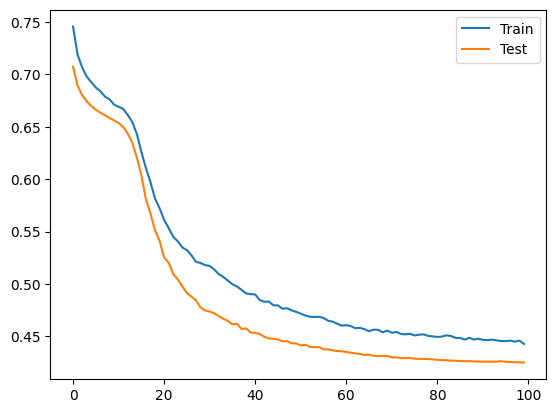

In [34]:
def plot_training(epochs, train_loss_per_epoch, test_loss_per_epoch):
    plt.figure()
    plt.plot(np.arange(epochs), train_loss_per_epoch, label="Train")
    plt.plot(np.arange(epochs), test_loss_per_epoch, label='Test')
    plt.legend()
    plt.show()
    return

plot_training(EPOCHS, train_loss_per_epoch, test_loss_per_epoch)

In [60]:
# Predict test set
trained_model.eval()
Xtest_tensor = torch.tensor(Xtest.values, dtype=torch.float)
y_pred = trained_model.forward(Xtest_tensor)
y_hat = torch.argmax(y_pred, 1).detach().cpu().numpy()

proba_layer = nn.Softmax(dim=1)
y_pred_proba = proba_layer(y_pred)
y_pred_proba_arr = y_pred_proba.detach().cpu().numpy()

print(confusion_matrix(ytest, y_hat))
print(classification_report(ytest, y_hat))
print("Accuracy: ", accuracy_score(ytest, y_hat))
print("ROC AUC:", roc_auc_score(ytest, y_pred_proba_arr[:,1]))


[[5766 3004]
 [  80 1150]]
              precision    recall  f1-score   support

           0       0.99      0.66      0.79      8770
           1       0.28      0.93      0.43      1230

    accuracy                           0.69     10000
   macro avg       0.63      0.80      0.61     10000
weighted avg       0.90      0.69      0.74     10000

Accuracy:  0.6916
ROC AUC: 0.8472519027356751


In [67]:
# Compare cpu and gpu
start_time = time.time()
_,_,_ = train(trainloader, testloader, class_no, no_features, LR, EPOCHS, 
              proc_device='cpu', verbose=False)
print(f'Training time: ', time.time() - start_time)

start_time = time.time()
_,_,_ = train(trainloader, testloader, class_no, no_features, LR, EPOCHS, 
              proc_device='cuda:0', verbose=False)
print(f'Training time: ', time.time() - start_time)

Training time:  102.68916487693787
Training time:  123.67443490028381
